In [37]:
"""
RFQ Internal Pressure Scan
=============================
Produces:
  - Figure 3.10: Ion count rate vs. internal RFQ pressure

Internal RFQ pressure cannot be measured directly, so it's derived from the
externally indicated gauge pressure via a vacuum conductance model (Appendix
A.2, Dickel's general conductance formula, Eq. A.1-A.3). Measured with the
drift tube installed, at Vpp=320V, 1144kHz, 1.79W heating power.
"""

import numpy as np
import re
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

In [38]:
# ==========================================================================
# EQUATIONS USED (Appendix A.2)
# ==========================================================================
#
# Dickel's general conductance formula (PhD thesis, Univ. Giessen 2010, Eq. 2.83-2.85),
# valid for arbitrary L/D ratio (short tube, long tube, and orifice limits all handled
# by the same formula, verified against known limiting cases):
#
#     C = 3.63 * A * sqrt(T/M) * [1 + (3/16)*(L*Circumference/A)]^-1     [L/s]
#
#   A, L, Circumference in cm/cm^2; T in K; M = molar mass in g/mol
#
# Used for both tubing segments (T-chamber -> turbo) and apertures (real 0.5mm thickness).
#
# PCB stack-gap conductance: NOT included. This hardware uses continuous metal
# spacers running the full board length (unlike the PEEK-spacer design with
# deliberate gas-inlet/ventilation openings described in Fowler-Davis's thesis),
# expected to substantially seal the inter-layer gap. Gas escape is therefore
# modeled as occurring through the two apertures only.
#
# Series combination (sequential stages, e.g. tubing segments + turbo):
#     1/C_total = sum(1/C_i)
#
# Parallel combination (independent escape routes from the same volume,
# e.g. the two apertures, both opening from the RFQ interior):
#     C_total = sum(C_i)
#
# Gas correction factor (N2-calibrated gauge -> true He pressure):
#     P_true = P_indicated / f_He          [f_He ~ 0.18]
#
# Background subtraction (isolates He-only signal): each row is background-
# subtracted against its own run's minimum raw gauge reading (the no-gas
# baseline taken at the start of that scan), per Eq. A.2 -- see
# compute_P_RFQ_per_run() below, rather than a single hardcoded pair of
# readings.
#
# Throughput / RFQ pressure:
#     Q = P_Tchamber * S_path
#     P_RFQ = Q / C_RFQ
#
# ==========================================================================

def dickel_general_C(D_mm, L_mm, T=300, M_gas=4.003):
    """Dickel's thesis Eq 2.84 -- valid for tubes AND apertures of any L/D ratio."""
    D_cm = D_mm / 10
    L_cm = L_mm / 10
    A = np.pi / 4 * D_cm**2
    C_circ = np.pi * D_cm
    return 3.63 * A * np.sqrt(T / M_gas) * (1 / ((3/16) * (L_cm * C_circ / A) + 1))

def combine_series(conductances_Ls):
    return 1 / sum(1 / c for c in conductances_Ls)

def combine_parallel(conductances_Ls):
    return sum(conductances_Ls)

# ---------- Tubing path: T-junction gauge branch -> turbo ----------

segments = [
    {"diameter_mm": 150, "length_mm": 405},
    {"diameter_mm": 150, "length_mm": 260},
    {"diameter_mm": 100, "length_mm": 180},
]

tube_conductances = [dickel_general_C(s["diameter_mm"], s["length_mm"]) for s in segments]
S_turbo_he = 255

S_path = combine_series(tube_conductances + [S_turbo_he])
print(f"--- Tubing / pumping path ---")
print(f"Effective pumping speed at T-chamber: {S_path:.1f} L/s\n")

# ---------- Aperture conductances (real 0.5mm thickness, PARALLEL combination) ----------

C_aperture_2mm = dickel_general_C(2.0, 0.5)
C_aperture_1p12mm = dickel_general_C(1.12, 0.5)
C_RFQ = combine_parallel([C_aperture_2mm, C_aperture_1p12mm])

print(f"--- Aperture conductances (D=2mm & 1.12mm, L=0.5mm actual thickness) ---")
print(f"2mm aperture: {C_aperture_2mm:.4f} L/s")
print(f"1.12mm aperture: {C_aperture_1p12mm:.4f} L/s")
print(f"Combined (C_RFQ, parallel): {C_RFQ:.4f} L/s")

--- Tubing / pumping path ---
Effective pumping speed at T-chamber: 171.4 L/s

--- Aperture conductances (D=2mm & 1.12mm, L=0.5mm actual thickness) ---
2mm aperture: 0.8314 L/s
1.12mm aperture: 0.2319 L/s
Combined (C_RFQ, parallel): 1.0633 L/s


In [39]:
def read_mpa_file(filepath):
    """Parses REALTIME and TOTALSUM from an MPANT ASCII export."""
    realtime = None
    totalsum = None
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())
    return realtime, totalsum

def get_rate_and_uncertainty(filepath):
    realtime, totalsum = read_mpa_file(filepath)
    if realtime is None or totalsum is None:
        print(f"WARNING: couldn't parse REALTIME/TOTALSUM from {filepath}, skipping")
        return None, None
    rate = totalsum / realtime
    rate_unc = np.sqrt(totalsum) / realtime
    return rate, rate_unc

def parse_pres_filename(filepath):
    """Extract true pressure (mbar), run number, and gradient flag from filenames like
    PS_4.3_3.mpa (4.3e-3, run 1, gradient unknown/legacy)
    PS_4.3_3_2.mpa (4.3e-3, run 2, gradient unknown/legacy)
    PS_4.3_3_yes.mpa (4.3e-3, run 1, with gradient)
    PS_4.3_3_2_no.mpa (4.3e-3, run 2, without gradient)
    """
    basename = filepath.split("/")[-1]
    match = re.match(r"PS_(\d+(?:\.\d+)?)_(\d+)(?:_(\d+))?(?:_(yes|no))?\.mpa$", basename)
    if match is None:
        return None
    mantissa = float(match.group(1))
    exponent = int(match.group(2))
    run = int(match.group(3)) if match.group(3) else 1
    gradient = match.group(4)  # "yes", "no", or None for legacy files
    pressure_mbar = mantissa * 10**(-exponent)
    return pressure_mbar, run, gradient

pres_files = [f for f in glob.glob("Pressure/PS_*.mpa") if "Noise" not in f]

pres_runs = []
for filepath in pres_files:
    parsed = parse_pres_filename(filepath)
    if parsed is None:
        continue
    pressure_mbar, run, gradient = parsed
    pres_runs.append({
        "filepath": filepath, "pressure_mbar": pressure_mbar,
        "run": run, "gradient": gradient
    })

pres_df = pd.DataFrame(pres_runs).sort_values(["run", "gradient", "pressure_mbar"]).reset_index(drop=True)

pres_df["rate_hz"], pres_df["rate_unc_hz"] = zip(
    *pres_df["filepath"].apply(get_rate_and_uncertainty)
)

print(pres_df)

                       filepath  pressure_mbar  run gradient     rate_hz  \
0         Pressure/PS_2.1_6.mpa       0.000002    1      NaN  136.753959   
1         Pressure/PS_2.6_6.mpa       0.000003    1      NaN  134.565083   
2         Pressure/PS_3.1_6.mpa       0.000003    1      NaN  138.394672   
3         Pressure/PS_3.6_6.mpa       0.000004    1      NaN  135.573696   
4         Pressure/PS_4.2_6.mpa       0.000004    1      NaN  134.409711   
5         Pressure/PS_4.9_6.mpa       0.000005    1      NaN  137.472845   
6         Pressure/PS_6.0_6.mpa       0.000006    1      NaN  139.741535   
7         Pressure/PS_7.7_6.mpa       0.000008    1      NaN  132.977308   
8         Pressure/PS_9.8_6.mpa       0.000010    1      NaN  130.289948   
9         Pressure/PS_1.1_5.mpa       0.000011    1      NaN  125.271759   
10        Pressure/PS_1.3_5.mpa       0.000013    1      NaN  124.448473   
11        Pressure/PS_1.4_5.mpa       0.000014    1      NaN  123.344437   
12   Pressur

In [40]:
def compute_P_RFQ_per_run(df, f_He=0.18, S_path=S_path, C_RFQ=C_RFQ):
    """
    Background-subtracts each row using that row's OWN run's minimum
    raw reading as the background (i.e., the dedicated no-gas measurement
    taken during that same session), rather than a hardcoded constant.
    """
    df = df.copy()
    P_off_per_run = df.groupby("run")["pressure_mbar"].transform("min")
    P_Tchamber = (df["pressure_mbar"] - P_off_per_run) / f_He
    Q = P_Tchamber * S_path
    df["P_RFQ_mbar"] = Q / C_RFQ
    return df

pres_df = compute_P_RFQ_per_run(pres_df)
print(pres_df[["filepath", "pressure_mbar", "P_RFQ_mbar", "run"]])

                       filepath  pressure_mbar  P_RFQ_mbar  run
0         Pressure/PS_2.1_6.mpa       0.000002    0.000000    1
1         Pressure/PS_2.6_6.mpa       0.000003    0.000448    1
2         Pressure/PS_3.1_6.mpa       0.000003    0.000896    1
3         Pressure/PS_3.6_6.mpa       0.000004    0.001344    1
4         Pressure/PS_4.2_6.mpa       0.000004    0.001881    1
5         Pressure/PS_4.9_6.mpa       0.000005    0.002508    1
6         Pressure/PS_6.0_6.mpa       0.000006    0.003494    1
7         Pressure/PS_7.7_6.mpa       0.000008    0.005016    1
8         Pressure/PS_9.8_6.mpa       0.000010    0.006898    1
9         Pressure/PS_1.1_5.mpa       0.000011    0.007973    1
10        Pressure/PS_1.3_5.mpa       0.000013    0.009764    1
11        Pressure/PS_1.4_5.mpa       0.000014    0.010660    1
12   Pressure/PS_5.8_6_2_no.mpa       0.000006    0.000000    2
13   Pressure/PS_6.3_6_2_no.mpa       0.000006    0.000448    2
14   Pressure/PS_7.0_6_2_no.mpa       0.

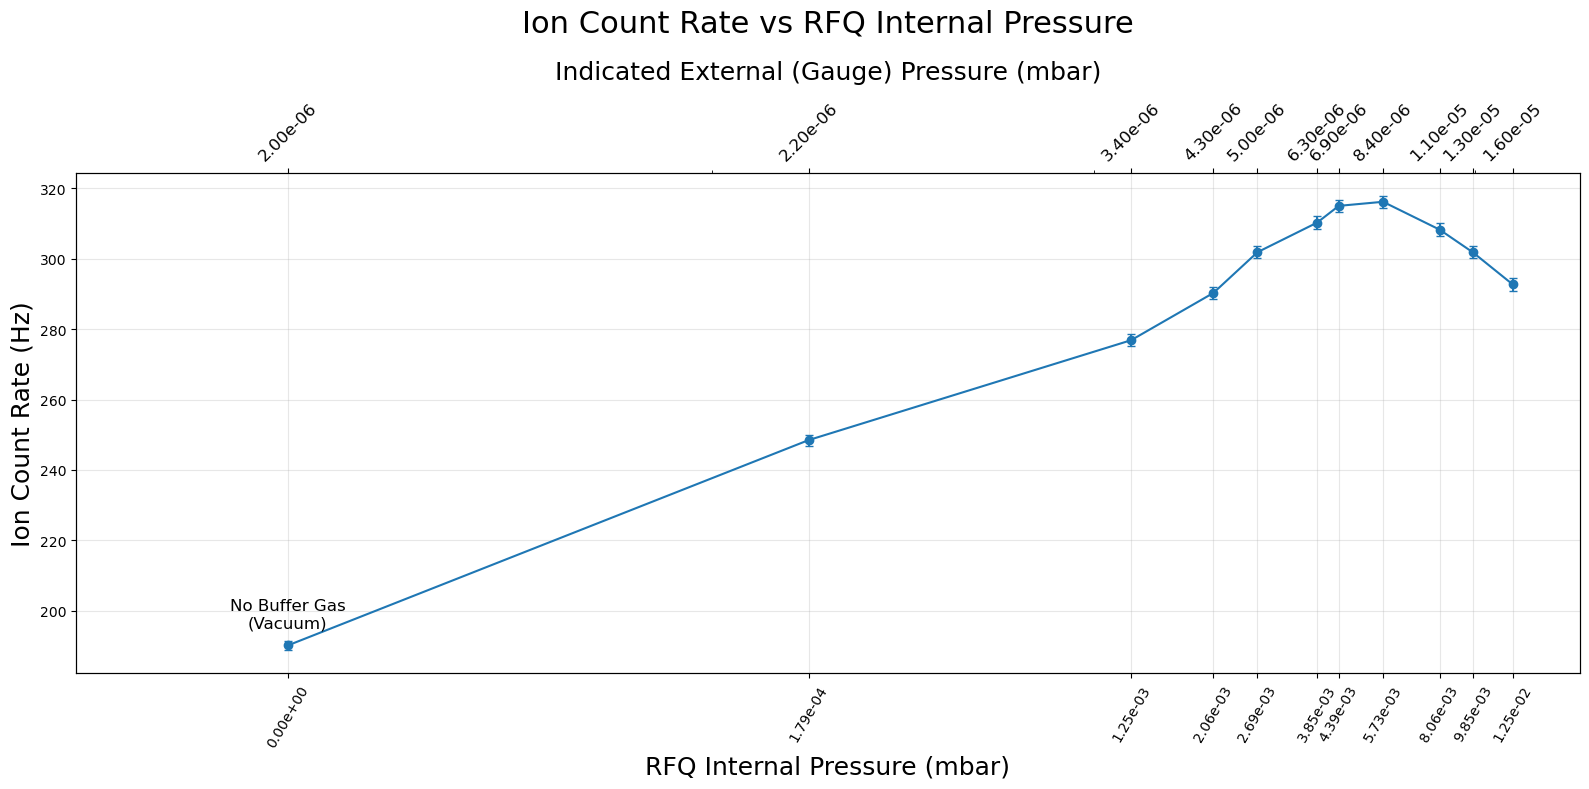

In [41]:
"""
Figure 3.10: Ion Count Rate vs. Internal RFQ Pressure
----------------------------------------------------------
Correct/final dataset (previously "Run 4"): with drift tube installed,
Vpp=320V, 1144kHz, 1.79W heating power. Earlier runs (no drift tube;
gradient/higher-Vpp variants) were preliminary and are not included here.
"""

pressure_scan = pres_df[pres_df["run"] == 4].sort_values("P_RFQ_mbar").reset_index(drop=True)

xmax = pressure_scan["P_RFQ_mbar"].max() * 1.5
linthresh = 1e-4

fig, ax1 = plt.subplots(figsize=(16, 8))

ax1.errorbar(
    pressure_scan["P_RFQ_mbar"], pressure_scan["rate_hz"], yerr=pressure_scan["rate_unc_hz"],
    marker="o", capsize=3, color="tab:blue", label="Ion count rate"
)

no_gas_row = pressure_scan[pressure_scan["P_RFQ_mbar"] <= 0]
if not no_gas_row.empty:
    x0 = no_gas_row["P_RFQ_mbar"].iloc[0]
    y0 = no_gas_row["rate_hz"].iloc[0]
    ax1.annotate("No Buffer Gas\n(Vacuum)", xy=(x0, y0), xytext=(x0, y0 + 5),
                 ha="center", fontsize=12)

ax1.set_xscale("symlog", linthresh=linthresh)
ax1.set_xlim(-linthresh/2, xmax)
ax1.set_xlabel("RFQ Internal Pressure (mbar)", fontsize=18)
ax1.set_ylabel("Ion Count Rate (Hz)", fontsize=18)
ax1.set_title("Ion Count Rate vs RFQ Internal Pressure", fontsize=22, pad=20)

all_ticks = sorted(list(pressure_scan["P_RFQ_mbar"]))
ax1.set_xticks(all_ticks)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2e}"))
ax1.xaxis.set_minor_locator(ticker.NullLocator())

ax1.grid(True, which="both", alpha=0.3)

ax2 = ax1.twiny()
ax2.set_xscale("symlog", linthresh=linthresh)
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(pressure_scan["P_RFQ_mbar"])
ax2.set_xticklabels([f"{p:.2e}" for p in pressure_scan["pressure_mbar"]], rotation=45, fontsize=12)
ax2.set_xlabel("Indicated External (Gauge) Pressure (mbar)", labelpad=15, fontsize=18)

plt.setp(ax1.get_xticklabels(), rotation=60)
plt.tight_layout()
plt.show()

In [42]:
import os
import shutil

def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)

def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw/, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)

    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)

    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing


description = [
    "Ion Count Rate vs. Internal RFQ Pressure",
    "Corresponds to Figure 3.10",
    "",
    "Purpose: characterizes how buffer-gas pressure inside the PCB RFQ",
    "affects ion transmission, testing the trade-off between improved",
    "buffer-gas cooling (which aids confinement) and increased collisional",
    "scattering (which degrades extraction through the exit aperture) as",
    "pressure increases. External (gauge) pressure is the directly measured",
    "quantity; internal RFQ pressure is derived from it via the vacuum",
    "conductance model described in Appendix A.2, since the RFQ interior",
    "cannot be measured directly.",
    "",
    "Conditions: Vpp=320V, 1144kHz, heating power=1.79W.",
    "",
    "Columns:",
    "  pressure_mbar   - Indicated external (gauge) pressure, raw reading (mbar)",
    "  p_rfq_mbar      - Derived RFQ internal pressure (mbar)",
    "  rate_hz         - Ion count rate (Hz)",
    "  rate_unc_hz     - Ion count rate uncertainty (Hz)",
    "  file            - Source .mpa filename",
]

export_cols_map = {
    "pressure_mbar": "pressure_mbar",
    "P_RFQ_mbar": "p_rfq_mbar",
    "rate_hz": "rate_hz",
    "rate_unc_hz": "rate_unc_hz",
    "filepath": "file",
}

export_df = pressure_scan[list(export_cols_map.keys())].rename(columns=export_cols_map)

export_figure_csv(export_df, "thesis/pressure_scan.csv", description)
print(export_df)

archive_raw_files(export_df["file"].str.split("/").str[-1].tolist(), "Pressure", "pressure_scan")

    pressure_mbar  p_rfq_mbar     rate_hz  rate_unc_hz  \
0        0.000002    0.000000  190.189312     1.377316   
1        0.000002    0.000179  248.488301     1.575934   
2        0.000003    0.001254  276.858967     1.663334   
3        0.000004    0.002060  290.284644     1.700919   
4        0.000005    0.002687  301.847845     1.734958   
5        0.000006    0.003852  310.249998     1.758221   
6        0.000007    0.004389  315.004492     1.773330   
7        0.000008    0.005733  316.162151     1.776949   
8        0.000011    0.008062  308.260604     1.755481   
9        0.000013    0.009854  301.811728     1.734751   
10       0.000016    0.012541  292.674654     1.708716   

                       file  
0   Pressure/PS_2.0_6_4.mpa  
1   Pressure/PS_2.2_6_4.mpa  
2   Pressure/PS_3.4_6_4.mpa  
3   Pressure/PS_4.3_6_4.mpa  
4   Pressure/PS_5.0_6_4.mpa  
5   Pressure/PS_6.3_6_4.mpa  
6   Pressure/PS_6.9_6_4.mpa  
7   Pressure/PS_8.4_6_4.mpa  
8   Pressure/PS_1.1_5_4.mpa  
9  

(['PS_2.0_6_4.mpa',
  'PS_2.2_6_4.mpa',
  'PS_3.4_6_4.mpa',
  'PS_4.3_6_4.mpa',
  'PS_5.0_6_4.mpa',
  'PS_6.3_6_4.mpa',
  'PS_6.9_6_4.mpa',
  'PS_8.4_6_4.mpa',
  'PS_1.1_5_4.mpa',
  'PS_1.3_5_4.mpa',
  'PS_1.6_5_4.mpa'],
 [])